In [1]:
import geopandas as gpd # used for reading and processing highway geometries
import pandas as pd
import numpy as np

# Load parquet file containing highway geometries and attributes
hw = gpd.read_parquet(r"C:\Users\INBA\Desktop\OneDrive - ELCOT\Inba\Anudip\Project\EV_Highway_Corridor_Reliability_Gap_Analysis\data\Raw datasets\National_Highways.parquet")


In [2]:
# Make a working copy
highways = hw.copy()

In [3]:
# View first few rows
highways.head()

,id,gid,objectid_1,objectid_2,objectid_3,objectid,i,j,state_ut,road_name,...,level_3,level_4,level_5,shape_leng,shape_le_1,shape_le_2,status,status_1,project_na,geometry
0,national_highway_uapdated_30_06_2022_departmen...,3113,16,2108,2097,2224,1699,1695,Karnataka,NH-66,...,Other National Highways,Coastal Roads,Others,0.35562340627,0.35562340627,0.35562340627,EXISTING,NaN,NaN,"LINESTRING (74.7359 13.34655, 74.73583 13.3463..."
1,national_highway_uapdated_30_06_2022_departmen...,3457,365,8280,8289,2224,1699,1695,Karnataka,NH-66,...,Other National Highways,Economic Corridors,Bharatmala Pariyojana Phase I,0.35562340627,0.35562340627,0.35562340627,EXISTING,NaN,NaN,"LINESTRING (74.7359 13.34655, 74.73583 13.3463..."
2,national_highway_uapdated_30_06_2022_departmen...,3460,368,8283,8292,2229,1695,1707,Karnataka,NH-66,...,Other National Highways,Economic Corridors,Bharatmala Pariyojana Phase I,0.60510779077,0.60510779077,0.60510779077,EXISTING,NaN,NaN,"LINESTRING (74.7359 13.34655, 74.73702 13.3495..."
3,national_highway_uapdated_30_06_2022_departmen...,3144,49,2207,2196,2229,1695,1707,Karnataka,NH-66,...,Other National Highways,Coastal Roads,Others,0.60510779077,0.60510779077,0.60510779077,EXISTING,NaN,NaN,"LINESTRING (74.7359 13.34655, 74.73702 13.3495..."
4,national_highway_uapdated_30_06_2022_departmen...,3175,80,2238,2227,2260,1697,1707,Karnataka,NH-766C,...,Other National Highways,NaN,NaN,0.40357750733,0.40357750733,0.40357750733,EXISTING,NaN,NaN,"LINESTRING (74.62976 13.85611, 74.63143 13.856..."


In [4]:
# Get dataset structure
highways.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 10317 entries, 0 to 10316
Data columns (total 65 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   id          10317 non-null  str     
 1   gid         10317 non-null  str     
 2   objectid_1  10317 non-null  str     
 3   objectid_2  10317 non-null  str     
 4   objectid_3  10317 non-null  str     
 5   objectid    10317 non-null  str     
 6   i           9398 non-null   str     
 7   j           9673 non-null   str     
 8   state_ut    10316 non-null  str     
 9   road_name   9835 non-null   str     
 10  greenfield  9456 non-null   str     
 11  road_type   10317 non-null  str     
 12  lane_statu  9516 non-null   str     
 13  completion  9453 non-null   str     
 14  completi_1  9453 non-null   str     
 15  speed_to_i  9394 non-null   str     
 16  ij          9398 non-null   str     
 17  length_2    10317 non-null  str     
 18  toll_type   9395 non-null   str     
 

In [5]:
# Missing values per column
highways.isnull().sum().sort_values(ascending=False)

project_na    9942
status_1      9938
add_road      8640
level_5       6253
ro_missing    5959
              ... 
gis_length       0
shape_le_2       0
shape_le_1       0
shape_leng       0
geometry         0
Length: 65, dtype: int64

In [6]:
# Check duplicate rows
print("Duplicate rows:", highways.duplicated().sum())

Duplicate rows: 0


In [7]:
# Check duplicate geometries
print("Duplicate geometries:", highways.geometry.duplicated().sum())

Duplicate geometries: 810


In [8]:
# Check duplicates by state, road name, and geometry
print("Duplicate (state_ut, road_name, geometry):",
      highways.duplicated(subset=["state_ut", "road_name", "geometry"]).sum())

Duplicate (state_ut, road_name, geometry): 806


In [9]:
# Select Relevant Columns 

keep_columns = [
    "state_ut",
    "road_name",
    "road_type",
    "lane_statu",
    "completion",
    "length_2",
    "gis_length",
    "traffic_1",
    "traffic_2",
    "traffic_3",
    "traffic_4",
    "traffic_5",
    "traffic_6",
    "traffic_7",
    "traffic_8",
    "traffic_9",
    "traffic_10",
    "traffic_11",
    "traffic_12",
    "traffic_13",
    "traffic_14",
    "category",
    "level_1",
    "level_2",
    "level_3",
    "level_4",
    "level_5",
    "status",
    "geometry"
]

highways_clean = highways[keep_columns].copy()

In [10]:
# Missing Value Summary

missing = pd.DataFrame({
    "missing_count": highways_clean.isnull().sum(),
    "missing_percent": highways_clean.isnull().mean() * 100
})

missing.sort_values("missing_percent", ascending=False)

,missing_count,missing_percent
level_5,6253,60.608704
level_4,5613,54.405350
level_2,5545,53.746244
level_3,1097,10.632936
traffic_6,919,8.907628
traffic_10,919,8.907628
traffic_9,919,8.907628
traffic_8,919,8.907628
traffic_7,919,8.907628
traffic_3,919,8.907628


In [11]:
# Automatically identify all columns whose names start with "traffic_".

traffic_cols = [
    col for col in highways_clean.columns
    if col.startswith("traffic_")
]

print("Traffic columns:")
print(traffic_cols)

Traffic columns:
['traffic_1', 'traffic_2', 'traffic_3', 'traffic_4', 'traffic_5', 'traffic_6', 'traffic_7', 'traffic_8', 'traffic_9', 'traffic_10', 'traffic_11', 'traffic_12', 'traffic_13', 'traffic_14']


In [12]:
# Check the unique values in traffic_2 to identify special non-numeric values that need cleaning.

print("traffic_2 unique values:")
print(highways_clean["traffic_2"].dropna().unique())

# Check whether traffic_12 and traffic_13 contain exactly the same values.

print("\ntraffic_12 and traffic_13 identical:")
print(
    highways_clean["traffic_12"].equals(
        highways_clean["traffic_13"]
    )
)

traffic_2 unique values:
<ArrowStringArray>
['Data Not Available', '0']
Length: 2, dtype: str

traffic_12 and traffic_13 identical:
True


In [13]:
# traffic_2 contains only "Data Not Available"/0 and is not useful for the planned numerical traffic analysis.
# traffic_13 is an exact duplicate of traffic_12.

highways_clean = highways_clean.drop(
    columns=["traffic_2", "traffic_13"]
)

print("Removed redundant columns: traffic_2, traffic_13")

Removed redundant columns: traffic_2, traffic_13


In [38]:
# Recreate the traffic column list after removing redundant columns.

traffic_cols = [col for col in highways_clean.columns
                if col.startswith("traffic_")]
# Convert the text value "Data Not Available" into NaN.

for col in traffic_cols:
    highways_clean[col] = highways_clean[col].replace(
        "Data Not Available", np.nan
    )

In [39]:
# Convert traffic columns from string/object values into numeric values.

for col in traffic_cols:
    highways_clean[col] = pd.to_numeric(
        highways_clean[col],
        errors="coerce"
    )

In [40]:
# Confirm that traffic columns are now numerical.

highways_clean[traffic_cols].dtypes

traffic_1     float64
traffic_3     float64
traffic_4     float64
traffic_5     float64
traffic_6     float64
traffic_7     float64
traffic_8     float64
traffic_9     float64
traffic_10    float64
traffic_11    float64
traffic_12    float64
traffic_14    float64
dtype: object

In [41]:
# Check missing values and negative values in traffic columns.
# Negative traffic values would be invalid, so this is a basic data-quality check.

traffic_validation = pd.DataFrame({
    "missing": highways_clean[traffic_cols].isna().sum(),
    "negative_values": (highways_clean[traffic_cols] < 0).sum()
})

display(traffic_validation)

,missing,negative_values
traffic_1,5989,0
traffic_3,5989,0
traffic_4,5989,0
traffic_5,5989,0
traffic_6,5989,0
traffic_7,5989,0
traffic_8,5989,0
traffic_9,5989,0
traffic_10,5989,0
traffic_11,5988,0


In [42]:
# Create the list level_1 through level_5.
level_cols = [f"level_{i}" for i in range(1, 6)]

# Count missing values at each classification level.
highways_clean[level_cols].isna().sum() .to_frame("missing_count")

,missing_count
level_1,69
level_2,5545
level_3,1097
level_4,5613
level_5,6253


In [19]:
for i in range(1, 5):
    parent = f"level_{i}"
    child = f"level_{i+1}"
    
    inconsistent = (
        highways_clean[child].notna() &
        highways_clean[parent].isna()
    ).sum()
    
    print(f"{child} present but {parent} missing:", inconsistent)

level_2 present but level_1 missing: 9
level_3 present but level_2 missing: 4449
level_4 present but level_3 missing: 0
level_5 present but level_4 missing: 56


In [43]:
# Display the distribution of highway completion status, including missing values.
highways_clean["completion"].value_counts(dropna=False)

completion
Already Completed    9088
NaN                   864
FY - 25               151
FY - 24                88
FY - 26                86
FY - 23                40
Name: count, dtype: int64

In [44]:
# Inspect the original lane-status values to identify inconsistent spellings/formats.
highways_clean["lane_statu"].value_counts(dropna=False).to_frame("count")

,count
lane_statu,
2L,5709
4L,2636
NaN,1154
6L,673
8L,90
<2L,30
4/6 L,12
2LPS,5
12L,3


In [45]:
# "IL" is not treated as a valid standard lane category for this analysis, so it is converted to missing.
highways_clean["lane_statu"] = highways_clean["lane_statu"].replace("IL", np.nan)

In [46]:
# Standardize different spellings/formats of the same lane classification.
lane_standardize = {
    "4 L": "4L",
    "6 L": "6L",
    "2l": "2L",
    "2 L": "2L",
    "2 LPS": "2LPS",
    "2 L PS": "2LPS",
     "2 LSP" :"2LPS"
}

highways_clean["lane_statu"] = highways_clean["lane_statu"].replace(
    lane_standardize
)

In [47]:
# Apply the standardization mapping.
highways_clean["lane_statu"].value_counts(dropna=False).to_frame("count")

,count
lane_statu,
2L,5709
4L,2636
NaN,1154
6L,673
8L,90
<2L,30
4/6 L,12
2LPS,5
12L,3


In [50]:
# Display the most common road names.
highways_clean["road_name"].value_counts(dropna=False).head(20).to_frame("count")

,count
road_name,
NaN,552
NH-44,349
NH-27,291
NH-66,226
NH-48,186
NH-53,152
NH-30,125
NH-16,122
NH-52,117


In [51]:
# "Delete" is a placeholder/instruction rather than a valid highway name, so convert it to missing.
highways_clean["road_name"] = highways_clean["road_name"].replace(
    "Delete", np.nan
)

In [52]:
# Verify the cleaned road-name distribution.
highways_clean["road_name"].value_counts(dropna=False).head(20).to_frame("count")

,count
road_name,
NaN,552
NH-44,349
NH-27,291
NH-66,226
NH-48,186
NH-53,152
NH-30,125
NH-16,122
NH-52,117


In [53]:
# Inspect category values and their frequencies.
highways_clean["category"].value_counts(dropna=False).to_frame("count")

,count
category,
Transport Infrastructure,10260
NaN,57


In [54]:
# Check whether each highway is existing, proposed, under construction, or missing status information.
highways_clean["status"].value_counts(dropna=False).to_frame("count")

,count
status,
EXISTING,9498
PRAPOSED,434
UNDER CONSTRUCTION,330
NaN,55


In [30]:
highways_clean["state_ut"].value_counts(dropna=False).to_frame("count")

,count
state_ut,
Maharashtra,1315
Uttar Pradesh,983
Andhra Pradesh,592
Madhya Pradesh,580
Tamil Nadu,546
Rajasthan,545
"Gujarat, Daman and Diu and Dadra and Nagar Haveli",542
West Bengal,511
Karnataka,454


In [55]:
# Correct inconsistent capitalization/spelling of Madhya Pradesh.
highways_clean["state_ut"] = highways_clean["state_ut"].replace({
    "MADHYA PRADESH": "Madhya Pradesh",
    "MADHYAPRADESH": "Madhya Pradesh"
})

In [56]:
# Identify rows where state information is missing.
missing_state = highways_clean[
    highways_clean["state_ut"].isna()
]

print("Rows with missing state:", len(missing_state))
# Display the important fields for the missing-state row(s) so they can be reviewed manually.
display(
    missing_state[
        ["state_ut", "road_name", "road_type", "length_2"]
    ]
)

Rows with missing state: 1


,state_ut,road_name,road_type,length_2
3912,NaN,NaN,National Highway,0.0


In [57]:
# Convert the source length fields from strings to numbers.
# Invalid values are converted to NaN.
highways_clean["length_2"] = pd.to_numeric(
    highways_clean["length_2"],
    errors="coerce"
)

highways_clean["gis_length"] = pd.to_numeric(
    highways_clean["gis_length"],
    errors="coerce"
)

In [58]:
# Check for negative GIS lengths.
print(
    "Negative gis_length values:",
    (highways_clean["gis_length"] < 0).sum()
)
# Check for zero-length records.
print(
    "Zero gis_length values:",
    (highways_clean["gis_length"] == 0).sum()
)
# Display minimum and maximum GIS length.
print(
    "Minimum gis_length:",
    highways_clean["gis_length"].min()
)

print(
    "Maximum gis_length:",
    highways_clean["gis_length"].max()
)

Negative gis_length values: 0
Zero gis_length values: 137
Minimum gis_length: 0.0
Maximum gis_length: 1107.30019697


In [59]:
# Identify records where both available length fields are zero.
both_zero = (
    (highways_clean["length_2"] == 0)
    &
    (highways_clean["gis_length"] == 0)
)

print(
    "Rows where both length fields are zero:",
    both_zero.sum()
)

Rows where both length fields are zero: 137


In [60]:
# Repeat the count for a clear validation output.
both_zero = (
    (highways_clean["length_2"] == 0) &
    (highways_clean["gis_length"] == 0)
).sum()

print("Both length fields are zero:", both_zero)

Both length fields are zero: 137


In [61]:
# Inspect whether zero-length records are LineString or MultiLineString geometries.
zero_length_rows = highways_clean[
    (
        (highways_clean["length_2"] == 0) &
        (highways_clean["gis_length"] == 0)
    )
]

display(
    zero_length_rows.geometry
    .geom_type
    .value_counts()
    .to_frame("count")
)

,count
LineString,124
MultiLineString,13


In [63]:
# Display the coordinate reference system.
# OGC:CRS84 uses longitude/latitude coordinates.
print(highways_clean.crs)


OGC:CRS84


In [64]:
# Verify that every record has a geometry.
print("Missing geometries:", highways_clean.geometry.isna().sum())
print("Empty geometries:", highways_clean.geometry.is_empty.sum())

Missing geometries: 0
Empty geometries: 0


In [ ]:
print("Invalid geometries:", (~highways_clean.geometry.is_valid).sum())

In [65]:
# Check for completely identical records.
print(
    "Exact duplicate rows:",
    highways_clean.duplicated().sum()
)

Exact duplicate rows: 64


In [66]:
# Store the original number of rows.
before = len(highways_clean)
# Remove exact duplicate records.
highways_clean = (
    highways_clean
    .drop_duplicates()
    .reset_index(drop=True)
)
# Store the number of rows after removing duplicates.
after = len(highways_clean)

print("Rows before:", before)
print("Rows after:", after)
print("Exact duplicate rows removed:", before - after)
# Confirm that no exact duplicates remain.
print(
    "Remaining exact duplicates:",
    highways_clean.duplicated().sum()
)

Rows before: 10317
Rows after: 10253
Exact duplicate rows removed: 64
Remaining exact duplicates: 0


In [67]:
# Even after removing exact duplicate rows, different records may still contain exactly the same geometry.
print("Duplicate geometries:", highways_clean.geometry.duplicated().sum())

Duplicate geometries: 746


In [68]:
# Create a unique key from geometry
highways_clean["_geom_key"] = highways_clean.geometry.to_wkb()

# Count missing important attributes
highways_clean["_missing"] = highways_clean[
    ["road_name", "lane_statu", "status", "completion"]
].isna().sum(axis=1)

before = len(highways_clean)

# Keep the row with fewer missing important attributes
highways_clean = (
    highways_clean
    .sort_values("_missing")
    .drop_duplicates("_geom_key")
    .drop(columns=["_geom_key", "_missing"])
    .reset_index(drop=True)
)

after = len(highways_clean)

print("Rows before geometry deduplication:", before)
print("Rows after geometry deduplication:", after)
print("Rows removed:", before - after)

Rows before geometry deduplication: 10253
Rows after geometry deduplication: 9507
Rows removed: 746


In [ ]:
print("Duplicate geometries after cleaning:",
      highways_clean.geometry.duplicated().sum())

In [69]:
# Reproject the highways to EPSG:6933, a projected CRS suitable for calculating distances/lengths in metres.
# Geometry length is then divided by 1000 to convert metres to km.
# The original geometry is NOT permanently changed because to_crs() is applied only for this calculation.
highways_clean["length_km"] = (
    highways_clean
    .to_crs("EPSG:6933")
    .geometry
    .length / 1000
)

print(highways_clean["length_km"].describe())

count    9.507000e+03
mean     1.750316e+01
std      2.666543e+01
min      2.833478e-09
25%      2.340348e+00
50%      8.263780e+00
75%      2.375901e+01
max      1.106535e+03
Name: length_km, dtype: float64


In [70]:
highways_nh = highways_clean[
    (highways_clean["road_type"] == "National Highway") &
    (highways_clean["status"] == "EXISTING")
].copy()

print("National Highway analysis dataset:", highways_nh.shape)

National Highway analysis dataset: (8512, 28)


In [71]:
# Display the number of records for each road type.
# This confirms that the cleaned dataset contains multiple road classifications.
display(
    highways_clean["road_type"]
    .value_counts(dropna=False)
    .to_frame("count")
)

,count
road_type,
National Highway,9276
State Expressway,93
Other Major Road,67
State Highway,64
Frontier Highway,7


In [72]:
print("========== FINAL VALIDATION ==========")

print("Shape:", highways_clean.shape)

print(
    "Duplicate rows:",
    highways_clean.duplicated().sum()
)

print(
    "Duplicate geometries:",
    highways_clean.geometry.duplicated().sum()
)

print(
    "Missing geometries:",
    highways_clean.geometry.isna().sum()
)

print(
    "Empty geometries:",
    highways_clean.geometry.is_empty.sum()
)

print(
    "Invalid geometries:",
    (~highways_clean.geometry.is_valid).sum()
)

print(
    "Index unique:",
    highways_clean.index.is_unique
)

print(
    "CRS:",
    highways_clean.crs
)

print("\nGeometry types:")
display(
    highways_clean.geometry
    .geom_type
    .value_counts()
    .to_frame("count")
)

print(
    "Highway analysis dataset:",
    highways_nh.shape
)

========== FINAL VALIDATION ==========
Shape: (9507, 28)
Duplicate rows: 0
Duplicate geometries: 0
Missing geometries: 0
Empty geometries: 0
Invalid geometries: 0
Index unique: True
CRS: OGC:CRS84

Geometry types:


,count
LineString,9253
MultiLineString,254


Highway analysis dataset: (8512, 28)


In [73]:
output_path = r"C:\Users\INBA\Desktop\OneDrive - ELCOT\Inba\Anudip\Project\EV_Highway_Corridor_Reliability_Gap_Analysis\data\Cleaned datasets\highways_clean.geojson"

highways_clean.to_file(output_path, driver="GeoJSON")

print("Saved successfully:", output_path)

Saved successfully: C:\Users\INBA\Desktop\OneDrive - ELCOT\Inba\Anudip\Project\EV_Highway_Corridor_Reliability_Gap_Analysis\data\Cleaned datasets\highways_clean.geojson


<Axes: >

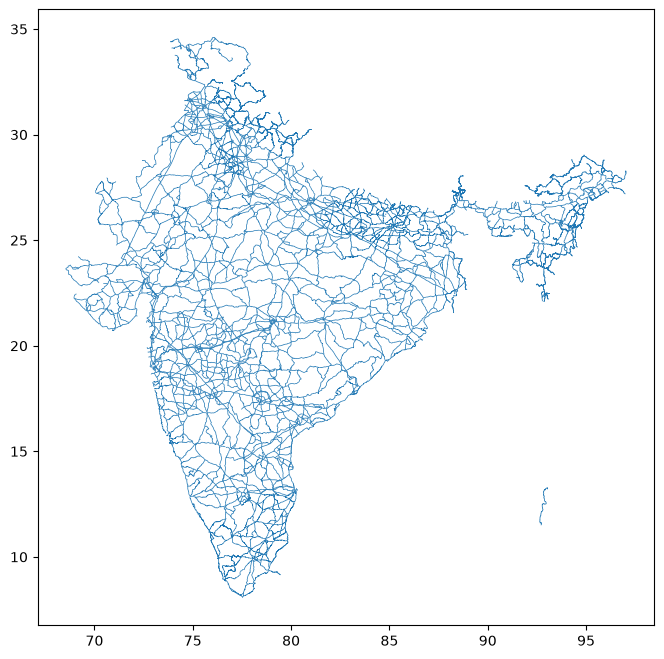

In [74]:
highways_clean.plot(figsize=(8, 8), linewidth=0.5)

In [75]:
highways_clean.head()

,state_ut,road_name,road_type,lane_statu,completion,length_2,gis_length,traffic_1,traffic_3,traffic_4,...,traffic_14,category,level_1,level_2,level_3,level_4,level_5,status,geometry,length_km
0,Karnataka,NH-369E,National Highway,2L,Already Completed,69334.787074,32.353026,NaN,NaN,NaN,...,NaN,Transport Infrastructure,Roadways,NaN,Other National Highways,NaN,NaN,EXISTING,"LINESTRING (74.91288 14.07832, 74.91282 14.078...",33.149834
1,Karnataka,NH-69,National Highway,2L,Already Completed,88125.717020,84.830525,239.0,49.0,66.0,...,9.0,Transport Infrastructure,Roadways,NaN,Other National Highways,NaN,NaN,EXISTING,"LINESTRING (74.9966 14.17001, 74.99642 14.1699...",12.501303
2,Karnataka,NH-69,National Highway,2L,Already Completed,24024.732492,19.808769,1363.0,430.0,581.0,...,71.0,Transport Infrastructure,Roadways,NaN,Other National Highways,NaN,NaN,EXISTING,"LINESTRING (75.06396 14.16047, 75.06435 14.160...",19.072426
3,Karnataka,NH-69,National Highway,2L,Already Completed,88125.717020,3.297874,239.0,49.0,66.0,...,9.0,Transport Infrastructure,Roadways,NaN,NaN,NaN,NaN,EXISTING,"LINESTRING (75.02311 14.16814, 75.02307 14.168...",1.304561
4,Karnataka,NH-66,National Highway,2L,Already Completed,23722.911195,99.163325,NaN,NaN,NaN,...,NaN,Transport Infrastructure,Roadways,National Highway Network,Other National Highways,Economic Corridors,Bharatmala Pariyojana Phase I,EXISTING,"LINESTRING (74.09374 14.90899, 74.09531 14.908...",102.577012
